In [16]:
# =========================================================
# 00_build_dataset_inventory.ipynb
#
# Dataset inventory for PRISMA/SIT reliability-audit paper
#
# Outputs:
#   tables/dataset_compact_summary.csv
#   tables/scene_inventory_full.csv
#   tables/scene_inventory_summer.csv
#   tables/class_inventory_full.csv
#   tables/class_inventory_summer.csv
#   tables/field_inventory_full.csv
#   tables/field_inventory_summer.csv
#   tables/class_persistence_groups.csv
#   tables/scene_class_distribution_full.csv
#   tables/scene_class_distribution_summer.csv
#   figures/scene_class_heatmap_full.pdf
#   figures/scene_class_heatmap_summer.pdf
#   reports/dataset_inventory_qc.md
#
# No GPU required.
# =========================================================

from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


# =========================================================
# PATHS
# =========================================================

BASE_PATH = Path("/kaggle/input/datasets/andgu2026/prisma-data2/")

DATA_FILE = BASE_PATH / "pretraining_data.csv"
LABEL_FILE = BASE_PATH / "pretraining_data_y.csv"
FIELD_FILE = BASE_PATH / "pretraining_data_field_ids.csv"
SCENE_FILE = BASE_PATH / "pretraining_data_scene_ids.csv"

OUT_DIR = Path("/kaggle/working")
TABLE_DIR = OUT_DIR / "tables"
FIGURE_DIR = OUT_DIR / "figures"
REPORT_DIR = OUT_DIR / "reports"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)


# =========================================================
# CONFIG
# =========================================================

INPUT_DIM = 191

CLASSES_TO_REMOVE = {224, 244, 334, 2123}

SUPPORTED_CLASSES = [
    2111, 2112, 2121,
    221, 222, 223,
    231, 241, 242, 243,
    311, 312, 313, 314,
    321, 322, 323,
    3241, 3242,
    331, 332, 333,
]

UNSUPPORTED_CLASSES = [224, 244, 334, 2123]



SUMMER_SCENES = {
    "Scena_1", "Scena_3", "Scena_4", "Scena_8", "Scena_9",
    "Scena_10", "Scena_12", "Scena_13", "Scena_14", "Scena_15",
    "Scena_23", "Scena_24", "Scena_25",
}

SETTINGS = ("full", "summer")

MAX_SAMPLES = 500_000
SUBSAMPLE_SEED = 42

MIN_PIXELS_PER_FIELD = 10

print("BASE_PATH:", BASE_PATH)
print("MAX_SAMPLES:", MAX_SAMPLES)
print("SUBSAMPLE_SEED:", SUBSAMPLE_SEED)


# =========================================================
# LOAD METADATA AND BUILD BASE DATAFRAME
# =========================================================

y = pd.read_csv(LABEL_FILE, header=None).iloc[:, 0].to_numpy()
field_ids = pd.read_csv(FIELD_FILE, header=None).iloc[:, 0].to_numpy()
scene_ids = pd.read_csv(SCENE_FILE, header=None).iloc[:, 0].to_numpy()

if not (len(y) == len(field_ids) == len(scene_ids)):
    raise ValueError(
        f"Row mismatch: y={len(y)}, field_ids={len(field_ids)}, "
        f"scene_ids={len(scene_ids)}"
    )

base_df = pd.DataFrame({
    "scene_id": scene_ids,
    "field_id": field_ids,
    "class_label": y,
})

base_df["scene_id"] = base_df["scene_id"].astype(str)
base_df["field_id"] = base_df["field_id"].astype(int)
base_df["class_label"] = base_df["class_label"].astype(int)

# Optional sample index, useful if later you subsample
base_df["sample_index"] = np.arange(len(base_df))


# =========================================================
# CLASS FILTERING
# =========================================================

filtered_df = base_df[~base_df["class_label"].isin(UNSUPPORTED_CLASSES)].copy()

missing_supported = sorted(
    set(SUPPORTED_CLASSES) - set(filtered_df["class_label"].unique())
)

extra_classes = sorted(
    set(filtered_df["class_label"].unique()) - set(SUPPORTED_CLASSES)
)

print("\nAFTER CLASS FILTERING")
print("Rows:", len(filtered_df))
print("Scenes:", filtered_df["scene_id"].nunique())
print("Fields:", filtered_df[["scene_id", "field_id"]].drop_duplicates().shape[0])
print("Classes:", sorted(filtered_df["class_label"].unique()))
print("Missing supported classes:", missing_supported)
print("Extra classes after filtering:", extra_classes)

if missing_supported:
    raise ValueError(f"Missing supported classes: {missing_supported}")

if extra_classes:
    raise ValueError(f"Unexpected classes after filtering: {extra_classes}")




# =========================================================
# SCENE INVENTORY WITHOUT SUBSAMPLING
# =========================================================

scene_inventory_full = (
    filtered_df
    .groupby("scene_id")
    .agg(
        n_pixels=("class_label", "size"),
        n_fields=("field_id", "nunique"),
        n_classes=("class_label", "nunique"),
    )
    .reset_index()
)

scene_inventory_full["scene_num"] = (
    scene_inventory_full["scene_id"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(int)
)

scene_inventory_full = (
    scene_inventory_full
    .sort_values("scene_num")
    .drop(columns="scene_num")
    .reset_index(drop=True)
)

scene_inventory_full.to_csv(
    TABLE_DIR / "scene_inventory_full_no_subsampling.csv",
    index=False
)

print("\nSCENE INVENTORY WITHOUT SUBSAMPLING")
print(scene_inventory_full)
print("Saved:", TABLE_DIR / "scene_inventory_full_no_subsampling.csv")

print("\nBASE DATAFRAME")
print("Rows:", len(base_df))
print("Scenes:", base_df["scene_id"].nunique())
print("Fields:", base_df[["scene_id", "field_id"]].drop_duplicates().shape[0])
print("Classes:", sorted(base_df["class_label"].unique()))

BASE_PATH: /kaggle/input/datasets/andgu2026/prisma-data2
MAX_SAMPLES: 500000
SUBSAMPLE_SEED: 42

AFTER CLASS FILTERING
Rows: 2498151
Scenes: 25
Fields: 190559
Classes: [np.int64(221), np.int64(222), np.int64(223), np.int64(231), np.int64(241), np.int64(242), np.int64(243), np.int64(311), np.int64(312), np.int64(313), np.int64(314), np.int64(321), np.int64(322), np.int64(323), np.int64(331), np.int64(332), np.int64(333), np.int64(2111), np.int64(2112), np.int64(2121), np.int64(3241), np.int64(3242)]
Missing supported classes: []
Extra classes after filtering: []

SCENE INVENTORY WITHOUT SUBSAMPLING
    scene_id  n_pixels  n_fields  n_classes
0    Scena_1     99997     12139         20
1    Scena_2     99922      4420         20
2    Scena_3     99918      7597         19
3    Scena_4     99994      7570         19
4    Scena_5     99926      4093         21
5    Scena_6     99940      3098         18
6    Scena_7    100000     10688         20
7    Scena_8     99901      8400         20

In [13]:
# =========================================================
# CLASS NAMES AND PERSISTENCE GROUPS
# =========================================================

CLASS_INFO = {
    222: {
        "class_name": "Fruit trees and minor fruit plantations",
        "persistence_group": "semi_dynamic",
    },
    223: {
        "class_name": "Olive groves",
        "persistence_group": "persistent",
    },
    311: {
        "class_name": "Broad-leaved forest",
        "persistence_group": "persistent",
    },
    313: {
        "class_name": "Mixed forest",
        "persistence_group": "semi_dynamic",
    },
    321: {
        "class_name": "Natural grassland, pasture, and fallow land",
        "persistence_group": "semi_dynamic",
    },
    322: {
        "class_name": "Shrubland",
        "persistence_group": "persistent",
    },
    323: {
        "class_name": "Sclerophyllous vegetation",
        "persistence_group": "persistent",
    },
    332: {
        "class_name": "Bare rock and outcrops",
        "persistence_group": "persistent",
    },
    2111: {
        "class_name": "Non-irrigated arable land",
        "persistence_group": "dynamic_agricultural",
    },
    2112: {
        "class_name": "Non-irrigated horticultural crops",
        "persistence_group": "dynamic_agricultural",
    },
    2121: {
        "class_name": "Irrigated arable land",
        "persistence_group": "dynamic_agricultural",
    },
    3241: {
        "class_name": "Natural recolonization areas",
        "persistence_group": "semi_dynamic",
    },
}

class_info_df = pd.DataFrame([
    {"class_label": 2111, "class_name": "Non-irrigated arable land", "class_short": "Non-ir. arable", "group": "Dynamic agr."},
    {"class_label": 2112, "class_name": "Non-irrigated horticultural crops", "class_short": "Non-ir. hortic.", "group": "Dynamic agr."},
    {"class_label": 2121, "class_name": "Irrigated arable land", "class_short": "Irr. arable", "group": "Dynamic agr."},

    {"class_label": 221, "class_name": "Vineyards", "class_short": "Vineyards", "group": "Persistent crop"},
    {"class_label": 222, "class_name": "Fruit trees and minor fruit plantations", "class_short": "Fruit trees", "group": "Persistent crop"},
    {"class_label": 223, "class_name": "Olive groves", "class_short": "Olive groves", "group": "Persistent crop"},

    {"class_label": 231, "class_name": "Pastures", "class_short": "Pastures", "group": "Semi-dyn."},
    {"class_label": 241, "class_name": "Annual crops associated with permanent crops", "class_short": "Ann./perm. crops", "group": "Dynamic agr."},
    {"class_label": 242, "class_name": "Complex cultivation patterns", "class_short": "Complex cultiv.", "group": "Dynamic agr."},
    {"class_label": 243, "class_name": "Agricultural areas with significant natural vegetation", "class_short": "Agric./natural veg.", "group": "Semi-dyn."},

    {"class_label": 311, "class_name": "Broad-leaved forest", "class_short": "Broadleaf forest", "group": "Persistent"},
    {"class_label": 312, "class_name": "Coniferous forest", "class_short": "Coniferous forest", "group": "Persistent"},
    {"class_label": 313, "class_name": "Mixed forest", "class_short": "Mixed forest", "group": "Persistent"},
    {"class_label": 314, "class_name": "Wooded pastures and meadows", "class_short": "Wooded past./meadows", "group": "Semi-dyn."},

    {"class_label": 321, "class_name": "Natural grassland, pasture, and fallow land", "class_short": "Grass/pasture", "group": "Semi-dyn."},
    {"class_label": 322, "class_name": "Shrubland", "class_short": "Shrubland", "group": "Persistent"},
    {"class_label": 323, "class_name": "Sclerophyllous vegetation", "class_short": "Scleroph. veg.", "group": "Persistent"},

    {"class_label": 3241, "class_name": "Natural recolonization areas", "class_short": "Recolonization", "group": "Semi-dyn."},
    {"class_label": 3242, "class_name": "Artificial recolonization areas", "class_short": "Young reforestation", "group": "Semi-dyn."},

    {"class_label": 331, "class_name": "Beaches, dunes, and sand areas", "class_short": "Beaches/dunes", "group": "Persistent"},
    {"class_label": 332, "class_name": "Bare rock and outcrops", "class_short": "Bare rock", "group": "Persistent"},
    {"class_label": 333, "class_name": "Sparsely vegetated areas", "class_short": "Sparse vegetation", "group": "Semi-dyn."},
])

class_info_path = TABLE_DIR / "class_persistence_groups.csv"
class_info_df.to_csv(class_info_path, index=False)

print("Saved:", class_info_path)
display(class_info_df)

Saved: /kaggle/working/tables/class_persistence_groups.csv


,class_label,class_name,class_short,group
0,2111,Non-irrigated arable land,Non-ir. arable,Dynamic agr.
1,2112,Non-irrigated horticultural crops,Non-ir. hortic.,Dynamic agr.
2,2121,Irrigated arable land,Irr. arable,Dynamic agr.
3,221,Vineyards,Vineyards,Persistent crop
4,222,Fruit trees and minor fruit plantations,Fruit trees,Persistent crop
5,223,Olive groves,Olive groves,Persistent crop
6,231,Pastures,Pastures,Semi-dyn.
7,241,Annual crops associated with permanent crops,Ann./perm. crops,Dynamic agr.
8,242,Complex cultivation patterns,Complex cultiv.,Dynamic agr.
9,243,Agricultural areas with significant natural ve...,Agric./natural veg.,Semi-dyn.


In [14]:
# =========================================================
# UTILS
# =========================================================

def natural_key(x):
    x = str(x)
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r"(\d+)", x)]


def read_single_column(path, name):
    print(f"Reading {name}: {path}")
    df = pd.read_csv(path, header=None)
    if df.shape[1] == 0:
        raise ValueError(f"{name} is empty: {path}")
    return df.iloc[:, 0]


def clean_labels(series):
    return pd.to_numeric(
        series.astype(str).str.strip(),
        errors="raise",
    ).astype(np.int64).values


def clean_field_ids(series):
    return pd.to_numeric(
        series.astype(str).str.strip(),
        errors="raise",
    ).astype(np.int64).values


def clean_scene_ids(series):
    return series.astype(str).str.strip().values


def make_class_id(class_labels):
    unique_labels = sorted(pd.unique(class_labels))
    label_to_id = {lab: i for i, lab in enumerate(unique_labels)}
    id_to_label = {i: lab for lab, i in label_to_id.items()}
    class_id = np.array([label_to_id[v] for v in class_labels], dtype=np.int64)
    return class_id, label_to_id, id_to_label


def subsample_balanced_by_scene(df, max_samples=500_000, seed=42):
    """
    Balanced-by-scene subsampling.
    Keeps approximately the same number of samples per scene.
    """
    if max_samples is None or len(df) <= max_samples:
        return df.copy()

    rng = np.random.default_rng(seed)

    scene_counts = df["scene_id"].value_counts().sort_index()
    scenes = list(scene_counts.index)

    base_quota = max_samples // len(scenes)
    remainder = max_samples % len(scenes)

    selected_indices = []

    print(f"\nBalanced-by-scene subsampling to {max_samples}")
    print(f"Scenes: {len(scenes)}, base quota: {base_quota}, remainder: {remainder}")

    for i, scene in enumerate(scenes):
        scene_idx = df.index[df["scene_id"] == scene].to_numpy()
        quota = base_quota + (1 if i < remainder else 0)
        quota = min(quota, len(scene_idx))

        chosen = rng.choice(scene_idx, size=quota, replace=False)
        selected_indices.append(chosen)

        print(f"  {scene}: selected {quota} / {len(scene_idx)}")

    selected_indices = np.concatenate(selected_indices)
    rng.shuffle(selected_indices)

    return df.loc[selected_indices].copy()


def majority_value(x):
    return x.value_counts().idxmax()


def majority_share(x):
    return x.value_counts(normalize=True).max()

In [15]:
# =========================================================
# LOAD RAW DATA
# =========================================================

print("Loading spectra...")
X = pd.read_csv(DATA_FILE, header=None).values.astype(np.float32)
print("X shape:", X.shape)

if X.shape[1] != INPUT_DIM:
    raise ValueError(f"Expected {INPUT_DIM} spectral bands, found {X.shape[1]}")

y_raw = read_single_column(LABEL_FILE, "labels")
field_raw = read_single_column(FIELD_FILE, "field ids")
scene_raw = read_single_column(SCENE_FILE, "scene ids")

y = clean_labels(y_raw)
field_ids = clean_field_ids(field_raw)
scene_ids = clean_scene_ids(scene_raw)

if not (len(X) == len(y) == len(field_ids) == len(scene_ids)):
    raise ValueError("Length mismatch between spectra, labels, field IDs, and scene IDs.")

print("Loaded rows:", len(X))
print("Unique raw classes:", sorted(pd.unique(y)))
print("Unique raw scenes:", len(pd.unique(scene_ids)))
print("Unique raw fields:", len(pd.unique(field_ids)))

Loading spectra...
X shape: (2500000, 191)
Reading labels: /kaggle/input/datasets/andgu2026/prisma-data2/pretraining_data_y.csv
Reading field ids: /kaggle/input/datasets/andgu2026/prisma-data2/pretraining_data_field_ids.csv
Reading scene ids: /kaggle/input/datasets/andgu2026/prisma-data2/pretraining_data_scene_ids.csv
Loaded rows: 2500000
Unique raw classes: [np.int64(221), np.int64(222), np.int64(223), np.int64(224), np.int64(231), np.int64(241), np.int64(242), np.int64(243), np.int64(244), np.int64(311), np.int64(312), np.int64(313), np.int64(314), np.int64(321), np.int64(322), np.int64(323), np.int64(331), np.int64(332), np.int64(333), np.int64(334), np.int64(2111), np.int64(2112), np.int64(2121), np.int64(2123), np.int64(3241), np.int64(3242)]
Unique raw scenes: 25
Unique raw fields: 19350


In [68]:
# =========================================================
# BUILD BASE METADATA DATAFRAME
# =========================================================
#
# To save memory, the inventory notebook does not keep the spectral bands
# after checking the input dimension. It only needs metadata.
# =========================================================

base_df = pd.DataFrame({
    "sample_index": np.arange(len(y), dtype=np.int64),
    "class_label": y,
    "field_id": field_ids,
    "scene_id": scene_ids,
})

raw_summary = {
    "raw_rows": int(len(base_df)),
    "raw_scenes": int(base_df["scene_id"].nunique()),
    "raw_fields": int(base_df["field_id"].nunique()),
    "raw_classes": sorted([int(v) for v in base_df["class_label"].unique()]),
}

print(json.dumps(raw_summary, indent=2))
display(base_df.head())

{
  "raw_rows": 2500000,
  "raw_scenes": 25,
  "raw_fields": 19350,
  "raw_classes": [
    221,
    222,
    223,
    224,
    231,
    241,
    242,
    243,
    244,
    311,
    312,
    313,
    314,
    321,
    322,
    323,
    331,
    332,
    333,
    334,
    2111,
    2112,
    2121,
    2123,
    3241,
    3242
  ]
}


,sample_index,class_label,field_id,scene_id
0,0,312,16415,Scena_1
1,1,323,18474,Scena_1
2,2,223,4962,Scena_1
3,3,221,3045,Scena_1
4,4,323,18296,Scena_1


In [69]:
# =========================================================
# CLASS FILTERING
# =========================================================

CLASSES_TO_REMOVE = [224, 244, 334, 2123]

RETAINED_CLASSES = [
    2111, 2112, 2121,
    221, 222, 223,
    231, 241, 242, 243,
    311, 312, 313, 314,
    321, 322, 323,
    3241, 3242,
    331, 332, 333,
]

filtered_df = base_df[~base_df["class_label"].isin(CLASSES_TO_REMOVE)].copy()

missing_retained = sorted(
    set(RETAINED_CLASSES) - set(filtered_df["class_label"].unique())
)

extra_classes = sorted(
    set(filtered_df["class_label"].unique()) - set(RETAINED_CLASSES)
)

print("After class filtering")
print("Rows:", len(filtered_df))
print("Scenes:", filtered_df["scene_id"].nunique())
print("Fields:", filtered_df["field_id"].nunique())
print("Classes:", sorted(filtered_df["class_label"].unique()))
print("Missing retained classes:", missing_retained)
print("Extra classes after filtering:", extra_classes)

if missing_retained:
    raise ValueError(f"Missing retained classes: {missing_retained}")

if extra_classes:
    raise ValueError(f"Unexpected classes after filtering: {extra_classes}")

After class filtering
Rows: 2498151
Scenes: 25
Fields: 19346
Classes: [np.int64(221), np.int64(222), np.int64(223), np.int64(231), np.int64(241), np.int64(242), np.int64(243), np.int64(311), np.int64(312), np.int64(313), np.int64(314), np.int64(321), np.int64(322), np.int64(323), np.int64(331), np.int64(332), np.int64(333), np.int64(2111), np.int64(2112), np.int64(2121), np.int64(3241), np.int64(3242)]
Missing retained classes: []
Extra classes after filtering: []


In [71]:
# =========================================================
# FULL-SCENE HEATMAP DATA WITHOUT SUBSAMPLING
# =========================================================

heatmap_df = filtered_df.copy()

# Add class metadata
heatmap_df = heatmap_df.merge(class_info_df, on="class_label", how="left")

missing = sorted(
    heatmap_df.loc[heatmap_df["class_name"].isna(), "class_label"].unique()
)

if missing:
    raise ValueError(f"Missing class metadata for: {missing}")

print("\nFULL-SCENE HEATMAP DATA WITHOUT SUBSAMPLING")
print("Rows:", len(heatmap_df))
print("Scenes:", heatmap_df["scene_id"].nunique())
print("Fields:", heatmap_df[["scene_id", "field_id"]].drop_duplicates().shape[0])
print("Classes:", sorted(heatmap_df["class_label"].unique()))


FULL-SCENE HEATMAP DATA WITHOUT SUBSAMPLING
Rows: 2498151
Scenes: 25
Fields: 190559
Classes: [np.int64(221), np.int64(222), np.int64(223), np.int64(231), np.int64(241), np.int64(242), np.int64(243), np.int64(311), np.int64(312), np.int64(313), np.int64(314), np.int64(321), np.int64(322), np.int64(323), np.int64(331), np.int64(332), np.int64(333), np.int64(2111), np.int64(2112), np.int64(2121), np.int64(3241), np.int64(3242)]


In [73]:
# =========================================================
# SCENE-CLASS DISTRIBUTION WITHOUT SUBSAMPLING
# =========================================================

scene_class_counts_full = (
    heatmap_df
    .groupby(["scene_id", "class_label"])
    .size()
    .rename("n_pixels")
    .reset_index()
)

scene_totals_full = (
    heatmap_df
    .groupby("scene_id")
    .size()
    .rename("scene_pixels")
    .reset_index()
)

scene_class_distribution_full = scene_class_counts_full.merge(
    scene_totals_full,
    on="scene_id",
    how="left"
)

scene_class_distribution_full["share"] = (
    scene_class_distribution_full["n_pixels"]
    / scene_class_distribution_full["scene_pixels"]
)

# Save long-format CSV
scene_class_distribution_full.to_csv(
    OUT_DIR / "scene_class_distribution_full_no_subsampling.csv",
    index=False
)

print(scene_class_distribution_full.head())
print("Saved:", OUT_DIR / "scene_class_distribution_full_no_subsampling.csv")


  scene_id  class_label  n_pixels  scene_pixels     share
0  Scena_1          221      3308         99997  0.033081
1  Scena_1          222      4070         99997  0.040701
2  Scena_1          223     27566         99997  0.275668
3  Scena_1          231        67         99997  0.000670
4  Scena_1          241      2487         99997  0.024871
Saved: /kaggle/working/scene_class_distribution_full_no_subsampling.csv


In [74]:
# =========================================================
# PIVOT MATRIX
# =========================================================

heatmap_matrix = (
    scene_class_distribution_full
    .pivot_table(
        index="scene_id",
        columns="class_label",
        values="share",
        fill_value=0
    )
)

# Sort scenes numerically
heatmap_matrix = heatmap_matrix.reset_index()
heatmap_matrix["scene_num"] = (
    heatmap_matrix["scene_id"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(int)
)

heatmap_matrix = (
    heatmap_matrix
    .sort_values("scene_num")
    .drop(columns="scene_num")
    .set_index("scene_id")
)

# Sort / select supported classes
heatmap_matrix = heatmap_matrix.reindex(columns=SUPPORTED_CLASSES, fill_value=0)

print(heatmap_matrix.shape)
heatmap_matrix.head()

(25, 22)


class_label,2111,2112,2121,221,222,223,231,241,242,243,...,313,314,321,322,323,3241,3242,331,332,333
scene_id,,,,,,,,,,,,,,,,,,,,,
Scena_1,0.358761,0.00025,0.000000,0.033081,0.040701,0.275668,0.000670,0.024871,0.001000,0.00001,...,0.001850,0.004940,0.026731,0.010400,0.046391,0.002740,0.000510,0.00006,0.000000,0.000300
Scena_2,0.595464,0.00002,0.006485,0.044104,0.011239,0.070275,0.004894,0.002482,0.000630,0.00000,...,0.016002,0.022267,0.169302,0.009427,0.000100,0.000320,0.002112,0.00000,0.001851,0.007956
Scena_3,0.372045,0.00008,0.000000,0.033237,0.096929,0.255219,0.001091,0.004063,0.001221,0.00034,...,0.013971,0.010288,0.145900,0.001952,0.006115,0.001261,0.001531,0.00000,0.000000,0.000200
Scena_4,0.267636,0.00058,0.000000,0.006070,0.096656,0.486009,0.000000,0.045203,0.000910,0.00000,...,0.001540,0.001980,0.016781,0.003110,0.026812,0.001420,0.000230,0.00083,0.002820,0.000030
Scena_5,0.440886,0.00005,0.318906,0.098513,0.004734,0.103166,0.000080,0.000210,0.000210,0.00008,...,0.000140,0.001421,0.015772,0.010258,0.000130,0.000110,0.000000,0.00001,0.000080,0.000230


Saved: /kaggle/working/figures/scene_class_heatmap_full_no_subsampling.png
Saved: /kaggle/working/figures/scene_class_heatmap_full_no_subsampling.pdf


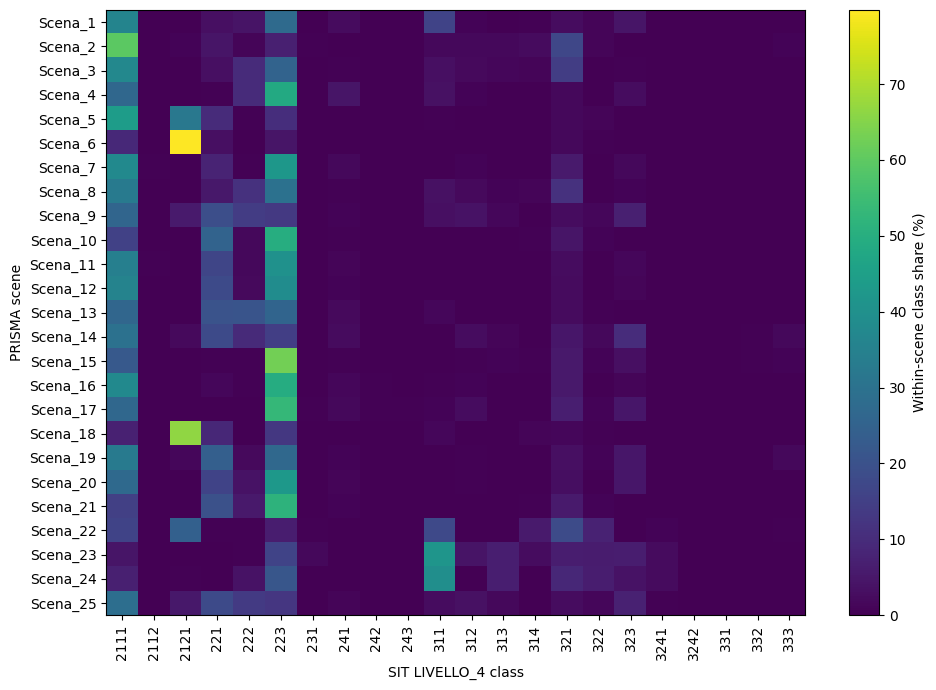

In [75]:
import matplotlib.pyplot as plt
import numpy as np

FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Convert to percentage
M = 100 * heatmap_matrix

fig, ax = plt.subplots(figsize=(10, 7))

im = ax.imshow(M.values, aspect="auto")

ax.set_xticks(np.arange(M.shape[1]))
ax.set_xticklabels(M.columns.astype(str), rotation=90)

ax.set_yticks(np.arange(M.shape[0]))
ax.set_yticklabels(M.index.astype(str))


ax.set_xlabel("SIT LIVELLO_4 class")
ax.set_ylabel("PRISMA scene")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Within-scene class share (%)")

plt.tight_layout()

out_png = FIG_DIR / "scene_class_heatmap_full_no_subsampling.png"
out_pdf = FIG_DIR / "scene_class_heatmap_full_no_subsampling.pdf"

plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")

print("Saved:", out_png)
print("Saved:", out_pdf)

In [43]:
from pathlib import Path
import numpy as np
import pandas as pd

# =========================================================
# CONFIGURATION
# =========================================================

OUT_DIR = Path("/Users/andreaguerriero/Documents/Nuovo_tentativo/PRISMA_AUDIT/tables")
OUT_DIR.mkdir(parents=True, exist_ok=True)

MIN_CLASS_PIXELS = 1000
EPS = 1e-12

# Use the full audit dataframe before scene-balanced subsampling
df = filtered_df.copy()

# ---------------------------------------------------------
# IMPORTANT: define spectral feature columns
# ---------------------------------------------------------
# Option A: if your spectral columns are named like band_001, band_002, ...
FEATURE_COLS = [c for c in df.columns if c.startswith("band_")]

# Option B: if your spectral columns have another prefix, edit this line.
# FEATURE_COLS = [c for c in df.columns if c.startswith("B")]

print("Number of spectral bands:", len(FEATURE_COLS))
print("Rows before filtering:", len(df))
print("Scenes:", df["scene_id"].nunique())
print("Classes:", df["class_label"].nunique())

if len(FEATURE_COLS) == 0:
    raise ValueError("No spectral feature columns found. Please define FEATURE_COLS manually.")

Number of spectral bands: 0
Rows before filtering: 2498151
Scenes: 25
Classes: 22


ValueError: No spectral feature columns found. Please define FEATURE_COLS manually.

In [44]:
# =========================================================
# KEEP ONLY SUPPORTED CLASSES
# =========================================================

class_counts = df["class_label"].value_counts()

supported_classes = class_counts[class_counts >= MIN_CLASS_PIXELS].index.tolist()
unsupported_classes = class_counts[class_counts < MIN_CLASS_PIXELS].index.tolist()

print("Supported classes:", len(supported_classes), sorted(supported_classes))
print("Unsupported classes:", len(unsupported_classes), sorted(unsupported_classes))

df_sup = df[df["class_label"].isin(supported_classes)].copy()

print("Rows in supported classes:", len(df_sup))
print("Field-scene units:", df_sup[["scene_id", "field_id"]].drop_duplicates().shape[0])

Supported classes: 22 [221, 222, 223, 231, 241, 242, 243, 311, 312, 313, 314, 321, 322, 323, 331, 332, 333, 2111, 2112, 2121, 3241, 3242]
Unsupported classes: 0 []
Rows in supported classes: 2498151
Field-scene units: 190559


In [45]:
# =========================================================
# COMPUTE CLASS PROTOTYPES
# =========================================================

def l2_normalize(X, eps=1e-12):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(norms, eps)

prototypes = {}

for cls in sorted(supported_classes):
    X = df_sup.loc[df_sup["class_label"] == cls, FEATURE_COLS].to_numpy(dtype=np.float32)
    
    # Pixel-level L2 normalization
    Xn = l2_normalize(X, EPS)
    
    # Component-wise median prototype
    p = np.median(Xn, axis=0).astype(np.float32)
    
    # Normalize prototype again
    p = p / max(np.linalg.norm(p), EPS)
    
    prototypes[cls] = p

print("Computed prototypes:", len(prototypes))

Computed prototypes: 22


In [46]:
# =========================================================
# COMPUTE PIXEL-LEVEL DISTANCES TO ASSIGNED CLASS PROTOTYPE
# =========================================================

parts = []

for cls in sorted(supported_classes):
    idx = df_sup["class_label"] == cls
    
    meta = df_sup.loc[idx, ["scene_id", "field_id", "class_label"]].copy()
    X = df_sup.loc[idx, FEATURE_COLS].to_numpy(dtype=np.float32)
    
    Xn = l2_normalize(X, EPS)
    p = prototypes[cls].astype(np.float32)
    
    # Cosine similarity with assigned-class prototype
    cos_sim = Xn @ p
    cos_sim = np.clip(cos_sim, -1.0, 1.0)
    
    # Spectral Angle Distance
    d_sad = np.arccos(cos_sim)
    
    # Euclidean distance in normalized spectral space
    d_euc = np.linalg.norm(Xn - p[None, :], axis=1)
    
    meta["d_sad"] = d_sad.astype(np.float32)
    meta["d_euc"] = d_euc.astype(np.float32)
    
    parts.append(meta)
    
    print(f"Class {cls}: {len(meta):,} pixels")

pixel_distances = pd.concat(parts, ignore_index=True)

out_csv = OUT_DIR / "pixel_spectral_distances_full.csv"
pixel_distances.to_csv(out_csv, index=False)

print("Saved:", out_csv)
print(pixel_distances.head())
print(pixel_distances.shape)

Class 221: 244,804 pixels
Class 222: 117,809 pixels
Class 223: 734,113 pixels
Class 231: 3,693 pixels
Class 241: 25,210 pixels
Class 242: 3,785 pixels
Class 243: 1,719 pixels
Class 311: 138,395 pixels
Class 312: 28,387 pixels
Class 313: 23,916 pixels
Class 314: 17,369 pixels
Class 321: 142,643 pixels
Class 322: 33,325 pixels
Class 323: 67,041 pixels
Class 331: 1,941 pixels
Class 332: 2,500 pixels
Class 333: 6,517 pixels
Class 2111: 675,874 pixels
Class 2112: 1,831 pixels
Class 2121: 218,679 pixels
Class 3241: 7,423 pixels
Class 3242: 1,177 pixels
Saved: /Users/andreaguerriero/Documents/Nuovo_tentativo/PRISMA_AUDIT/tables/pixel_spectral_distances_full.csv
  scene_id  field_id  class_label     d_sad  d_euc
0  Scena_1      3045          221  1.570796    0.0
1  Scena_1      6127          221  1.570796    0.0
2  Scena_1      3127          221  1.570796    0.0
3  Scena_1      3148          221  1.570796    0.0
4  Scena_1      9081          221  1.570796    0.0
(2498151, 5)


In [48]:
######
# funzione aggiunta per ottenere SCENE INVENTORY su tutti i pixel, no sampling


# =========================================================
# SCENE INVENTORY BEFORE SUBSAMPLING
# =========================================================

def build_scene_inventory_no_subsampling(filtered_df, setting="full"):
    df = filtered_df.copy()

    if setting == "summer":
        df = df[df["scene_id"].isin(SUMMER_SCENES)].copy()
    elif setting == "full":
        pass
    else:
        raise ValueError(f"Unknown setting: {setting}")

    df["setting"] = setting

    # Unique field-scene units
    field_counts = (
        df[["scene_id", "field_id"]]
        .drop_duplicates()
        .groupby("scene_id")
        .size()
        .rename("n_fields")
    )

    # Pixel counts
    pixel_counts = (
        df.groupby("scene_id")
        .size()
        .rename("n_pixels")
    )

    # Number of original SIT classes per scene
    class_counts = (
        df.groupby("scene_id")["class_label"]
        .nunique()
        .rename("n_classes")
    )

    # Dominant class and dominant share
    class_pixel_counts = (
        df.groupby(["scene_id", "class_label"])
        .size()
        .rename("class_pixels")
        .reset_index()
    )

    total_pixels = (
        class_pixel_counts.groupby("scene_id")["class_pixels"]
        .sum()
        .rename("total_pixels")
        .reset_index()
    )

    class_pixel_counts = class_pixel_counts.merge(total_pixels, on="scene_id")
    class_pixel_counts["class_share"] = (
        class_pixel_counts["class_pixels"] / class_pixel_counts["total_pixels"]
    )

    dominant = (
        class_pixel_counts
        .sort_values(["scene_id", "class_pixels"], ascending=[True, False])
        .drop_duplicates("scene_id")
        .set_index("scene_id")[["class_label", "class_share"]]
        .rename(columns={
            "class_label": "dominant_class",
            "class_share": "dominant_class_share"
        })
    )

    inventory = pd.concat(
        [pixel_counts, field_counts, class_counts, dominant],
        axis=1
    ).reset_index()

    inventory["setting"] = setting

    # Ordine scene
    inventory["scene_num"] = (
        inventory["scene_id"]
        .astype(str)
        .str.extract(r"(\d+)")
        .astype(int)
    )

    inventory = (
        inventory
        .sort_values("scene_num")
        .drop(columns="scene_num")
        .reset_index(drop=True)
    )

    return inventory

In [57]:
#############
# da rimuovere per effettuare samplig




scene_inventory_full_no_sampling = build_scene_inventory_no_subsampling(
    filtered_df,
    setting="full"
)

print(scene_inventory_full_no_sampling)
print("Total pixels:", scene_inventory_full_no_sampling["n_pixels"].sum())
print("Scenes:", scene_inventory_full_no_sampling["scene_id"].nunique())
print("Fields:", scene_inventory_full_no_sampling["n_fields"].sum())

    scene_id  n_pixels  n_fields  n_classes  dominant_class  \
0    Scena_1     99997     12139         20            2111   
1    Scena_2     99922      4420         20            2111   
2    Scena_3     99918      7597         19            2111   
3    Scena_4     99994      7570         19             223   
4    Scena_5     99926      4093         21            2111   
5    Scena_6     99940      3098         18            2121   
6    Scena_7    100000     10688         20             223   
7    Scena_8     99901      8400         20            2111   
8    Scena_9     99968      8409         22            2111   
9   Scena_10     99949      8509         21             223   
10  Scena_11     99997     10701         21             223   
11  Scena_12     99996     10605         20             223   
12  Scena_13     99991     12046         20            2111   
13  Scena_14    100000      6294         21            2111   
14  Scena_15     99871      4807         22            

In [61]:
#############
# da rimuovere per effettuare samplig

scene_inventory_full_no_sampling.to_csv(
    OUT_DIR / "scene_inventory_full_no_sampling.csv",
    index=False
)

In [51]:
# non usare senza subsampling




# =========================================================
# PREPARE SETTING DATAFRAME
# =========================================================

def prepare_setting_dataframe(filtered_df, setting):
    df = filtered_df.copy()

    if setting == "summer":
        df = df[df["scene_id"].isin(SUMMER_SCENES)].copy()
    elif setting == "full":
        pass
    else:
        raise ValueError(f"Unknown setting: {setting}")

    df["setting"] = setting

    print("\n" + "=" * 100)
    print(f"SETTING BEFORE SUBSAMPLING: {setting}")
    print("=" * 100)
    print("Rows:", len(df))
    print("Scenes:", df["scene_id"].nunique())
    print("Fields:", df["field_id"].nunique())
    print("Classes:", sorted(df["class_label"].unique()))

    df = subsample_balanced_by_scene(
        df,
        max_samples=MAX_SAMPLES,
        seed=SUBSAMPLE_SEED,
    )

    df = df.sort_values("sample_index").reset_index(drop=True)

    class_id, label_to_id, id_to_label = make_class_id(df["class_label"].values)
    df["class_id"] = class_id

    df = df.merge(class_info_df, on="class_label", how="left")

    if df["class_name"].isna().any():
        missing = sorted(df.loc[df["class_name"].isna(), "class_label"].unique())
        raise ValueError(f"Missing class metadata for: {missing}")

    df["subsample_seed"] = SUBSAMPLE_SEED
    df["max_samples"] = MAX_SAMPLES

    print("\nSETTING AFTER SUBSAMPLING")
    print("Rows:", len(df))
    print("Scenes:", df["scene_id"].nunique())
    print("Fields:", df["field_id"].nunique())
    print("Classes:", sorted(df["class_label"].unique()))

    return df, label_to_id, id_to_label


setting_dfs = {}
label_maps = {}

for setting in SETTINGS:
    df_setting, label_to_id, id_to_label = prepare_setting_dataframe(filtered_df, setting)
    setting_dfs[setting] = df_setting
    label_maps[setting] = {
        "label_to_id": label_to_id,
        "id_to_label": id_to_label,
    }


SETTING BEFORE SUBSAMPLING: full
Rows: 2498151
Scenes: 25
Fields: 19346
Classes: [np.int64(221), np.int64(222), np.int64(223), np.int64(231), np.int64(241), np.int64(242), np.int64(243), np.int64(311), np.int64(312), np.int64(313), np.int64(314), np.int64(321), np.int64(322), np.int64(323), np.int64(331), np.int64(332), np.int64(333), np.int64(2111), np.int64(2112), np.int64(2121), np.int64(3241), np.int64(3242)]

Balanced-by-scene subsampling to 500000
Scenes: 25, base quota: 20000, remainder: 0
  Scena_1: selected 20000 / 99997
  Scena_10: selected 20000 / 99949
  Scena_11: selected 20000 / 99997
  Scena_12: selected 20000 / 99996
  Scena_13: selected 20000 / 99991
  Scena_14: selected 20000 / 100000
  Scena_15: selected 20000 / 99871
  Scena_16: selected 20000 / 99943
  Scena_17: selected 20000 / 100000
  Scena_18: selected 20000 / 99962
  Scena_19: selected 20000 / 99993
  Scena_2: selected 20000 / 99922
  Scena_20: selected 20000 / 99984
  Scena_21: selected 20000 / 99982
  Scena

ValueError: Missing class metadata for: [np.int64(221), np.int64(231), np.int64(241), np.int64(242), np.int64(243), np.int64(312), np.int64(314), np.int64(331), np.int64(333), np.int64(3242)]

In [59]:
# =========================================================
# INVENTORY TABLE FUNCTIONS
# =========================================================

def build_scene_inventory(df, setting):
    scene_inventory = (
        df.groupby("scene_id")
        .agg(
            n_pixels=("sample_index", "count"),
            n_fields=("field_id", "nunique"),
            n_classes=("class_label", "nunique"),
            dominant_class=("class_label", majority_value),
            dominant_class_share=("class_label", majority_share),
        )
        .reset_index()
        .sort_values("scene_id", key=lambda s: s.map(natural_key))
    )

    scene_inventory["setting"] = setting
    scene_inventory["subset"] = np.where(
        scene_inventory["scene_id"].isin(SUMMER_SCENES),
        "summer",
        "full_only",
    )

    scene_inventory = scene_inventory[
        [
            "setting",
            "scene_id",
            "subset",
            "n_pixels",
            "n_fields",
            "n_classes",
            "dominant_class",
            "dominant_class_share",
        ]
    ]

    return scene_inventory


def build_class_inventory(df, setting):
    class_inventory = (
        df.groupby(["class_label", "class_id", "class_name", "persistence_group"])
        .agg(
            n_pixels=("sample_index", "count"),
            n_scenes=("scene_id", "nunique"),
            n_fields=("field_id", "nunique"),
            pixels_per_scene_median=("scene_id", lambda s: df.loc[s.index].groupby("scene_id").size().median()),
            pixels_per_scene_min=("scene_id", lambda s: df.loc[s.index].groupby("scene_id").size().min()),
            pixels_per_scene_max=("scene_id", lambda s: df.loc[s.index].groupby("scene_id").size().max()),
        )
        .reset_index()
        .sort_values("class_label")
    )

    class_inventory["setting"] = setting

    class_inventory = class_inventory[
        [
            "setting",
            "class_label",
            "class_id",
            "class_name",
            "persistence_group",
            "n_pixels",
            "n_scenes",
            "n_fields",
            "pixels_per_scene_median",
            "pixels_per_scene_min",
            "pixels_per_scene_max",
        ]
    ]

    return class_inventory


def build_field_inventory(df, setting):
    field_inventory = (
        df.groupby(["field_id", "scene_id"])
        .agg(
            n_pixels=("sample_index", "count"),
            n_classes_in_field=("class_label", "nunique"),
            dominant_class=("class_label", majority_value),
            dominant_class_share=("class_label", majority_share),
        )
        .reset_index()
    )

    field_inventory["setting"] = setting
    field_inventory["eligible_for_field_audit"] = field_inventory["n_pixels"] >= MIN_PIXELS_PER_FIELD

    # Add class metadata for dominant class.
    field_inventory = field_inventory.merge(
        class_info_df.rename(columns={"class_label": "dominant_class"}),
        on="dominant_class",
        how="left",
    )

    field_inventory = field_inventory[
        [
            "setting",
            "field_id",
            "scene_id",
            "n_pixels",
            "n_classes_in_field",
            "dominant_class",
            "class_name",
            "persistence_group",
            "dominant_class_share",
            "eligible_for_field_audit",
        ]
    ]

    return field_inventory


def build_scene_class_distribution(df, setting):
    dist = (
        df.groupby(["scene_id", "class_label"])
        .size()
        .reset_index(name="n_pixels")
    )

    total_per_scene = (
        df.groupby("scene_id")
        .size()
        .reset_index(name="scene_pixels")
    )

    dist = dist.merge(total_per_scene, on="scene_id", how="left")
    dist["scene_share"] = dist["n_pixels"] / dist["scene_pixels"]
    dist["setting"] = setting

    dist = dist.merge(class_info_df, on="class_label", how="left")

    dist = dist[
        [
            "setting",
            "scene_id",
            "class_label",
            "class_name",
            "persistence_group",
            "n_pixels",
            "scene_pixels",
            "scene_share",
        ]
    ]

    return dist

In [60]:
# =========================================================
# BUILD AND SAVE INVENTORY TABLES
# =========================================================

scene_inventories = []
class_inventories = []
field_inventories = []
scene_class_distributions = []

for setting, df in setting_dfs.items():
    scene_inventory = build_scene_inventory(df, setting)
    class_inventory = build_class_inventory(df, setting)
    field_inventory = build_field_inventory(df, setting)
    scene_class_distribution = build_scene_class_distribution(df, setting)

    scene_inventory_path = TABLE_DIR / f"scene_inventory_{setting}.csv"
    class_inventory_path = TABLE_DIR / f"class_inventory_{setting}.csv"
    field_inventory_path = TABLE_DIR / f"field_inventory_{setting}.csv"
    scene_class_path = TABLE_DIR / f"scene_class_distribution_{setting}.csv"

    scene_inventory.to_csv(scene_inventory_path, index=False)
    class_inventory.to_csv(class_inventory_path, index=False)
    field_inventory.to_csv(field_inventory_path, index=False)
    scene_class_distribution.to_csv(scene_class_path, index=False)

    print("\nSaved:")
    print(scene_inventory_path)
    print(class_inventory_path)
    print(field_inventory_path)
    print(scene_class_path)

    scene_inventories.append(scene_inventory)
    class_inventories.append(class_inventory)
    field_inventories.append(field_inventory)
    scene_class_distributions.append(scene_class_distribution)

scene_inventory_all = pd.concat(scene_inventories, ignore_index=True)
class_inventory_all = pd.concat(class_inventories, ignore_index=True)
field_inventory_all = pd.concat(field_inventories, ignore_index=True)
scene_class_distribution_all = pd.concat(scene_class_distributions, ignore_index=True)

scene_inventory_all.to_csv(TABLE_DIR / "scene_inventory_all.csv", index=False)
class_inventory_all.to_csv(TABLE_DIR / "class_inventory_all.csv", index=False)
field_inventory_all.to_csv(TABLE_DIR / "field_inventory_all.csv", index=False)
scene_class_distribution_all.to_csv(TABLE_DIR / "scene_class_distribution_all.csv", index=False)

display(scene_inventory_all.head())
display(class_inventory_all.head())
display(field_inventory_all.head())

ValueError: No objects to concatenate

In [55]:
# =========================================================
# DATASET COMPACT SUMMARY
# =========================================================

summary_rows = []

for setting, df in setting_dfs.items():
    scene_counts = df["scene_id"].value_counts()
    field_counts = df.groupby("field_id").size()

    summary_rows.append({
        "setting": setting,
        "n_pixels": int(len(df)),
        "n_scenes": int(df["scene_id"].nunique()),
        "n_classes": int(df["class_label"].nunique()),
        "n_fields": int(df["field_id"].nunique()),
        "pixels_per_scene_median": float(scene_counts.median()),
        "pixels_per_scene_min": int(scene_counts.min()),
        "pixels_per_scene_max": int(scene_counts.max()),
        "pixels_per_field_median": float(field_counts.median()),
        "pixels_per_field_min": int(field_counts.min()),
        "pixels_per_field_max": int(field_counts.max()),
        "n_eligible_fields": int((field_counts >= MIN_PIXELS_PER_FIELD).sum()),
        "max_samples": int(MAX_SAMPLES),
        "subsample_seed": int(SUBSAMPLE_SEED),
    })

dataset_summary = pd.DataFrame(summary_rows)

summary_path = TABLE_DIR / "dataset_compact_summary.csv"
dataset_summary.to_csv(summary_path, index=False)

print("Saved:", summary_path)
display(dataset_summary)

Saved: /kaggle/working/tables/dataset_compact_summary.csv


""


In [56]:
# =========================================================
# HEATMAP: SCENE × CLASS DISTRIBUTION
# =========================================================

def make_scene_class_heatmap(scene_class_distribution, setting):
    pivot = scene_class_distribution.pivot_table(
        index="scene_id",
        columns="class_label",
        values="scene_share",
        fill_value=0.0,
    )

    # Natural sorting for scenes and numeric sorting for classes.
    pivot = pivot.loc[sorted(pivot.index, key=natural_key), sorted(pivot.columns)]

    fig_width = 8
    fig_height = max(4, 0.25 * len(pivot.index) + 1.5)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    im = ax.imshow(pivot.values, aspect="auto")

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels([str(c) for c in pivot.columns], rotation=45, ha="right")

    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    ax.set_xlabel("SIT class")
    ax.set_ylabel("PRISMA scene")
    ax.set_title(f"Scene-class distribution after filtering and subsampling ({setting})")
    #ax.set_title(f"Scene-class distribution for main interpreted SIT classes")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Within-scene class share")

    fig.tight_layout()

    fig_path_pdf = FIGURE_DIR / f"scene_class_heatmap_{setting}.pdf"
    #fig_path_pdf = FIGURE_DIR / f"scene_class_heatmap.pdf"

    fig_path_png = FIGURE_DIR / f"scene_class_heatmap_{setting}.png"

    fig.savefig(fig_path_pdf, bbox_inches="tight")
    fig.savefig(fig_path_png, dpi=180, bbox_inches="tight")

    plt.show()

    print("Saved:", fig_path_pdf)
    print("Saved:", fig_path_png)


for setting in SETTINGS:
    dist = scene_class_distribution_all[scene_class_distribution_all["setting"] == setting]
    make_scene_class_heatmap(dist, setting)

NameError: name 'scene_class_distribution_all' is not defined

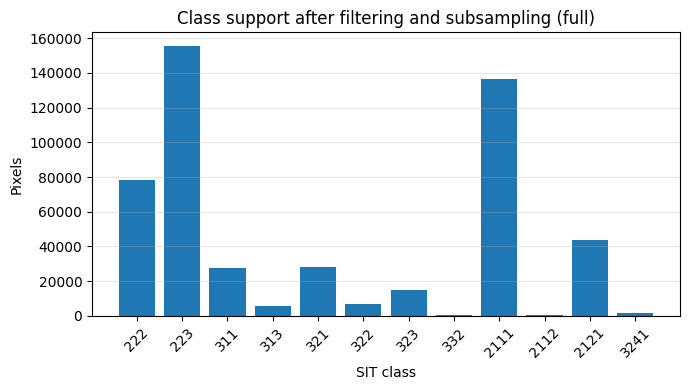

Saved: /kaggle/working/figures/class_support_full.pdf


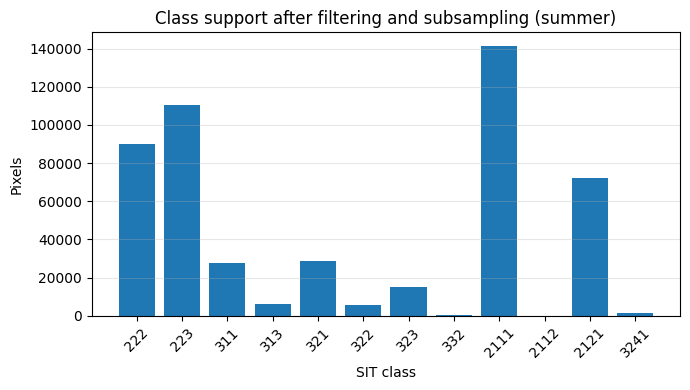

Saved: /kaggle/working/figures/class_support_summer.pdf


In [12]:
# =========================================================
# OPTIONAL: CLASS DISTRIBUTION BARPLOT
# =========================================================

def make_class_distribution_plot(class_inventory, setting):
    ci = class_inventory.sort_values("class_label")

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.bar(
        [str(c) for c in ci["class_label"]],
        ci["n_pixels"].values,
    )

    ax.set_xlabel("SIT class")
    ax.set_ylabel("Pixels")
    ax.set_title(f"Class support after filtering and subsampling ({setting})")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()

    fig_path = FIGURE_DIR / f"class_support_{setting}.pdf"
    fig.savefig(fig_path, bbox_inches="tight")
    plt.show()

    print("Saved:", fig_path)


for setting in SETTINGS:
    ci = class_inventory_all[class_inventory_all["setting"] == setting]
    make_class_distribution_plot(ci, setting)

In [13]:
# =========================================================
# QC CHECKS
# =========================================================

qc_rows = []

for setting, df in setting_dfs.items():
    scene_counts = df["scene_id"].value_counts()
    class_set = sorted([int(v) for v in df["class_label"].unique()])
    expected_classes = sorted(RETAINED_CLASSES)

    qc = {
        "setting": setting,
        "n_rows": int(len(df)),
        "n_scenes": int(df["scene_id"].nunique()),
        "n_fields": int(df["field_id"].nunique()),
        "n_classes": int(df["class_label"].nunique()),
        "classes_match_expected": bool(class_set == expected_classes),
        "has_removed_classes": bool(df["class_label"].isin(CLASSES_TO_REMOVE).any()),
        "min_scene_pixels": int(scene_counts.min()),
        "max_scene_pixels": int(scene_counts.max()),
        "median_scene_pixels": float(scene_counts.median()),
        "sample_index_unique": bool(df["sample_index"].is_unique),
        "class_id_null": bool(df["class_id"].isna().any()),
        "scene_id_null": bool(df["scene_id"].isna().any()),
        "field_id_null": bool(df["field_id"].isna().any()),
    }

    if setting == "full":
        qc["expected_n_scenes"] = 25
    elif setting == "summer":
        qc["expected_n_scenes"] = 13

    qc["scene_count_ok"] = bool(qc["n_scenes"] == qc["expected_n_scenes"])
    qc["status"] = "PASS" if (
        qc["classes_match_expected"]
        and not qc["has_removed_classes"]
        and qc["scene_count_ok"]
        and qc["sample_index_unique"]
        and not qc["class_id_null"]
        and not qc["scene_id_null"]
        and not qc["field_id_null"]
    ) else "FAIL"

    qc_rows.append(qc)

qc_df = pd.DataFrame(qc_rows)
qc_path = REPORT_DIR / "dataset_inventory_qc.csv"
qc_df.to_csv(qc_path, index=False)

print("Saved:", qc_path)
display(qc_df)

Saved: /kaggle/working/reports/dataset_inventory_qc.csv


,setting,n_rows,n_scenes,n_fields,n_classes,classes_match_expected,has_removed_classes,min_scene_pixels,max_scene_pixels,median_scene_pixels,sample_index_unique,class_id_null,scene_id_null,field_id_null,expected_n_scenes,scene_count_ok,status
0,full,500000,25,17507,12,True,False,20000,20000,20000.0,True,False,False,False,25,True,PASS
1,summer,500000,13,16971,12,True,False,38461,38462,38462.0,True,False,False,False,13,True,PASS


In [14]:
# =========================================================
# MARKDOWN QC REPORT
# =========================================================

md_path = REPORT_DIR / "dataset_inventory_qc.md"

with open(md_path, "w") as f:
    f.write("# Dataset Inventory QC Report\n\n")

    f.write("## Input files\n\n")
    f.write(f"- Spectra: `{DATA_FILE}`\n")
    f.write(f"- Labels: `{LABEL_FILE}`\n")
    f.write(f"- Field IDs: `{FIELD_FILE}`\n")
    f.write(f"- Scene IDs: `{SCENE_FILE}`\n\n")

    f.write("## Configuration\n\n")
    f.write(f"- Input dimension: `{INPUT_DIM}`\n")
    f.write(f"- Removed classes: `{sorted(CLASSES_TO_REMOVE)}`\n")
    f.write(f"- Retained classes: `{RETAINED_CLASSES}`\n")
    f.write(f"- Max samples per setting: `{MAX_SAMPLES}`\n")
    f.write(f"- Subsample seed: `{SUBSAMPLE_SEED}`\n")
    f.write(f"- Minimum pixels per field: `{MIN_PIXELS_PER_FIELD}`\n\n")

    f.write("## Raw dataset summary\n\n")
    for k, v in raw_summary.items():
        f.write(f"- {k}: `{v}`\n")

    f.write("\n## Compact summary\n\n")
    f.write(dataset_summary.to_markdown(index=False))
    f.write("\n\n")

    f.write("## QC checks\n\n")
    f.write(qc_df.to_markdown(index=False))
    f.write("\n\n")

    f.write("## Output tables\n\n")
    output_tables = [
        "dataset_compact_summary.csv",
        "scene_inventory_full.csv",
        "scene_inventory_summer.csv",
        "class_inventory_full.csv",
        "class_inventory_summer.csv",
        "field_inventory_full.csv",
        "field_inventory_summer.csv",
        "class_persistence_groups.csv",
        "scene_class_distribution_full.csv",
        "scene_class_distribution_summer.csv",
    ]

    for name in output_tables:
        f.write(f"- `tables/{name}`\n")

    f.write("\n## Output figures\n\n")
    output_figures = [
        "scene_class_heatmap_full.pdf",
        "scene_class_heatmap_summer.pdf",
        "class_support_full.pdf",
        "class_support_summer.pdf",
    ]

    for name in output_figures:
        f.write(f"- `figures/{name}`\n")

    f.write("\n## Interpretation note\n\n")
    f.write(
        "This notebook builds the dataset inventory used by the reliability-audit "
        "workflow. The inventory does not provide ground truth validation. It "
        "documents the class, scene, and field support after filtering and "
        "scene-balanced subsampling.\n"
    )

print("Saved:", md_path)

Saved: /kaggle/working/reports/dataset_inventory_qc.md


In [15]:
# =========================================================
# FINAL PREVIEW
# =========================================================

print("\nDATASET SUMMARY")
display(dataset_summary)

print("\nQC")
display(qc_df)

print("\nFULL CLASS INVENTORY")
display(class_inventory_all[class_inventory_all["setting"] == "full"])

print("\nSUMMER CLASS INVENTORY")
display(class_inventory_all[class_inventory_all["setting"] == "summer"])

print("\nOutput folder:", OUT_DIR)


DATASET SUMMARY


,setting,n_pixels,n_scenes,n_classes,n_fields,pixels_per_scene_median,pixels_per_scene_min,pixels_per_scene_max,pixels_per_field_median,pixels_per_field_min,pixels_per_field_max,n_eligible_fields,max_samples,subsample_seed
0,full,500000,25,12,17507,20000.0,20000,20000,17.0,1,2922,11655,500000,42
1,summer,500000,13,12,16971,38462.0,38461,38462,14.0,1,5584,10300,500000,42



QC


,setting,n_rows,n_scenes,n_fields,n_classes,classes_match_expected,has_removed_classes,min_scene_pixels,max_scene_pixels,median_scene_pixels,sample_index_unique,class_id_null,scene_id_null,field_id_null,expected_n_scenes,scene_count_ok,status
0,full,500000,25,17507,12,True,False,20000,20000,20000.0,True,False,False,False,25,True,PASS
1,summer,500000,13,16971,12,True,False,38461,38462,38462.0,True,False,False,False,13,True,PASS



FULL CLASS INVENTORY


,setting,class_label,class_id,class_name,persistence_group,n_pixels,n_scenes,n_fields,pixels_per_scene_median,pixels_per_scene_min,pixels_per_scene_max
0,full,222,0,Fruit trees and minor fruit plantations,semi_dynamic,78277,25,10706,2176.0,263,8091
1,full,223,1,Olive groves,persistent,155616,25,11911,5617.0,947,12800
2,full,311,2,Broad-leaved forest,persistent,27737,25,2349,152.0,12,8295
3,full,313,3,Mixed forest,semi_dynamic,5646,24,1142,60.0,3,1714
4,full,321,4,"Natural grassland, pasture, and fallow land",semi_dynamic,28292,25,6691,901.0,267,3634
5,full,322,5,Shrubland,persistent,6682,25,2116,125.0,2,1528
6,full,323,6,Sclerophyllous vegetation,persistent,14841,25,2768,338.0,1,2364
7,full,332,7,Bare rock and outcrops,persistent,487,19,161,15.0,1,86
8,full,2111,8,Non-irrigated arable land,dynamic_agricultural,136723,25,12689,5495.0,962,11990
9,full,2112,9,Non-irrigated horticultural crops,dynamic_agricultural,373,22,271,7.5,1,116



SUMMER CLASS INVENTORY


,setting,class_label,class_id,class_name,persistence_group,n_pixels,n_scenes,n_fields,pixels_per_scene_median,pixels_per_scene_min,pixels_per_scene_max
12,summer,222,0,Fruit trees and minor fruit plantations,semi_dynamic,90048,13,9435,5746.0,1417,15577
13,summer,223,1,Olive groves,persistent,110301,13,9745,7267.0,1906,20129
14,summer,311,2,Broad-leaved forest,persistent,27895,13,1775,531.0,12,16079
15,summer,313,3,Mixed forest,semi_dynamic,6170,13,715,82.0,1,3141
16,summer,321,4,"Natural grassland, pasture, and fallow land",semi_dynamic,28808,13,5199,1319.0,561,6428
17,summer,322,5,Shrubland,persistent,5820,13,1666,305.0,83,2353
18,summer,323,6,Sclerophyllous vegetation,persistent,15333,13,1672,280.0,2,4598
19,summer,332,7,Bare rock and outcrops,persistent,460,9,127,34.0,2,145
20,summer,2111,8,Non-irrigated arable land,dynamic_agricultural,141408,13,10468,11780.0,1935,23085
21,summer,2112,9,Non-irrigated horticultural crops,dynamic_agricultural,117,12,65,8.5,1,25



Output folder: /kaggle/working


In [17]:
from pathlib import Path
import shutil
import os

SOURCE_DIR = Path("/kaggle/working")
ZIP_BASE = Path("/kaggle/working/kaggle_working_backup")

# Avoid including a previous version of the same zip inside the new zip
zip_path = Path(str(ZIP_BASE) + ".zip")
if zip_path.exists():
    zip_path.unlink()

# Optional: remove older backup zips to avoid nesting large files
for old_zip in SOURCE_DIR.glob("kaggle_working_backup*.zip"):
    print("Removing old zip:", old_zip)
    old_zip.unlink()

print("Compressing:", SOURCE_DIR)
print("Output:", zip_path)

shutil.make_archive(
    base_name=str(ZIP_BASE),
    format="zip",
    root_dir=SOURCE_DIR
)

print("Done.")
print("ZIP file:", zip_path)
print("Size MB:", zip_path.stat().st_size / 1e6)


from IPython.display import FileLink

# Assicurati di essere nella cartella giusta (di solito /kaggle/working)
import os
os.chdir('/kaggle/working')

# Crea il link per il tuo file (cambia 'nome_del_tuo_file.zip')
FileLink('kaggle_working_backup.zip')



Compressing: /kaggle/working
Output: /kaggle/working/kaggle_working_backup.zip
Done.
ZIP file: /kaggle/working/kaggle_working_backup.zip
Size MB: 1.852188


/kaggle/working/kaggle_working_backup.zip